# S2: Umbralización

Este cuaderno construye de forma incremental el concepto de umbralización: partimos de la idea más sencilla (un corte manual en el histograma) y llegamos al método automático de Otsu, incluyendo la limpieza morfológica del resultado y la extracción de regiones de interés.


## Objetivos

- Entender qué es la umbralización y para qué se utiliza.
- Identificar el problema del umbral manual y motivar la necesidad de un método automático.
- Comprender el criterio de Otsu a través del histograma y la varianza entre clases.
- Aplicar limpieza morfológica paso a paso sobre la máscara binaria.
- Comparar resultados sobre imágenes con distinta iluminación.
- Etiquetar regiones detectadas y extraer sus propiedades geométricas.


In [ ]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure, filters, util, morphology, measure, data
from skimage.filters import threshold_otsu
import pandas as pd

# OpenCV es opcional
try:
    import cv2
    OPENCV_AVAILABLE = True
except Exception:
    OPENCV_AVAILABLE = False

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['image.cmap'] = 'gray'

## 1. ¿Qué es la umbralización?

Una imagen en escala de grises asigna a cada píxel un valor de intensidad entre 0 (negro) y 255 (blanco). La **umbralización** convierte esa imagen en una imagen **binaria**: cada píxel pasa a ser blanco (primer plano) o negro (fondo) según si su intensidad supera un valor de corte llamado **umbral**.

```
píxel ≥ umbral  →  blanco (True)   → primer plano / objeto
píxel  < umbral  →  negro  (False)  → fondo
```

Es una de las operaciones más utilizadas en visión por computador porque permite **aislar objetos del fondo** de forma muy eficiente, sin necesidad de modelos complejos.


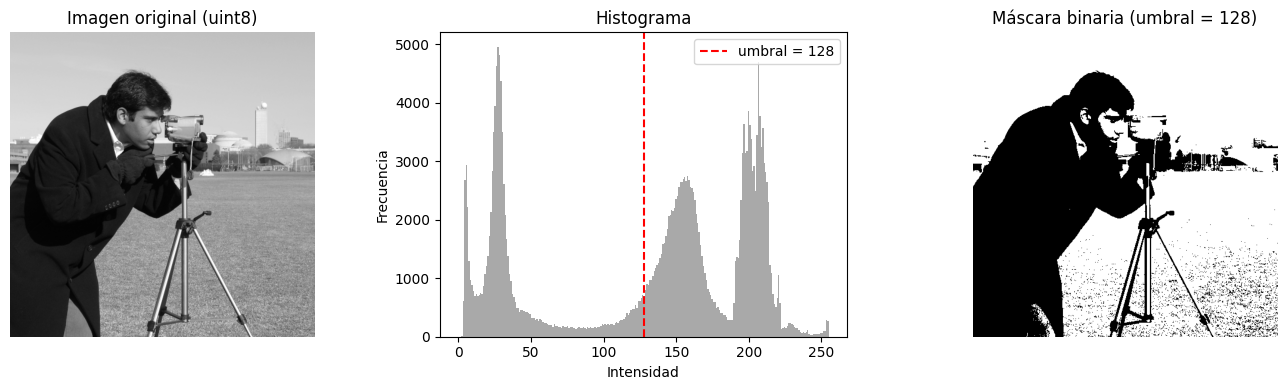

In [ ]:
# Imagen de ejemplo: 'camera' de skimage (fotógrafo sobre fondo gris)
img = data.camera()         # uint8 [0, 255]
img_f = util.img_as_float(img)  # float64 [0, 1]

# Aplicar un umbral manual arbitrario
umbral_manual = 128  # punto medio de [0, 255]
mascara_manual = img > umbral_manual  # True = primer plano

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagen original (uint8)')
axes[0].axis('off')

axes[1].hist(img.ravel(), bins=256, color='darkgray')
axes[1].axvline(umbral_manual, color='red', linestyle='--', label=f'umbral = {umbral_manual}')
axes[1].set_title('Histograma')
axes[1].set_xlabel('Intensidad')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

axes[2].imshow(mascara_manual, cmap='gray')
axes[2].set_title(f'Máscara binaria (umbral = {umbral_manual})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 2. El problema del umbral manual

El umbral de 128 puede funcionar en algunos casos, pero no es una solución general. Observa lo que ocurre cuando se prueban valores distintos sobre la misma imagen: un umbral demasiado bajo captura demasiado fondo como primer plano; uno demasiado alto pierde partes importantes del objeto.

Además, el umbral óptimo **cambia con cada imagen**: una imagen oscura necesita un umbral distinto al de una imagen brillante. Elegirlo manualmente para cada imagen no es práctico.


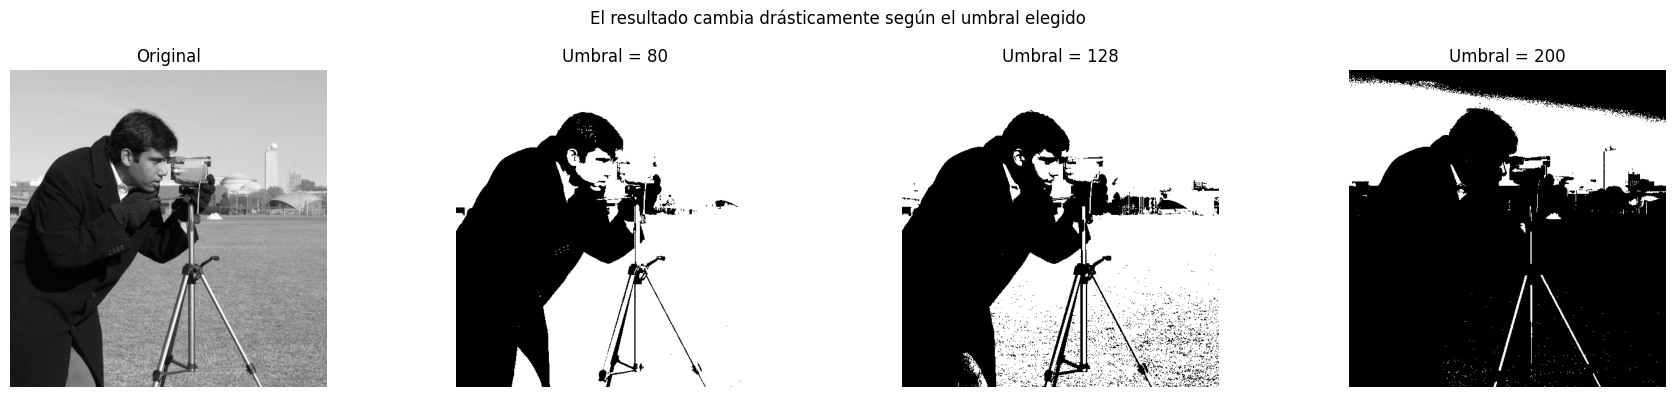

In [ ]:
# Comparación de tres umbrales manuales distintos
umbrales = [80, 128, 200]

fig, axes = plt.subplots(1, len(umbrales) + 1, figsize=(18, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, u in zip(axes[1:], umbrales):
    ax.imshow(img > u, cmap='gray')
    ax.set_title(f'Umbral = {u}')
    ax.axis('off')

plt.suptitle('El resultado cambia drásticamente según el umbral elegido', fontsize=12)
plt.tight_layout()
plt.show()

# Pregunta clave: ¿cómo elegir el umbral óptimo de forma automática?


## 3. El método de Otsu — ¿cómo encuentra el umbral óptimo?

### El problema
Dada una imagen en escala de grises, queremos separarla en dos grupos: **fondo** (píxeles oscuros) y **primer plano** (píxeles claros). Para ello necesitamos un umbral `t`: los píxeles por encima de `t` serán primer plano, los de abajo serán fondo. ¿Cómo elegir `t` automáticamente?

### La intuición
Si el histograma de la imagen tiene **dos picos bien diferenciados** (distribución bimodal), el umbral ideal está en el **valle** entre esos dos picos: es el punto donde menos píxeles pertenecen a ninguno de los dos grupos, es decir, donde la separación es más limpia.

![image.png](attachment:image.png)

### La matemática
Otsu prueba todos los posibles umbrales y para cada uno mide qué tan **compactos** (con poca varianza interna) son los dos grupos resultantes. El umbral ganador es el que produce los dos grupos más homogéneos posibles, o equivalentemente, el que **maximiza la diferencia entre los dos grupos**.

### Cuándo funciona bien y cuándo no
- ✓ Imágenes con histograma claramente bimodal (fondo uniforme + objeto bien definido).
- ✗ Imágenes con iluminación desigual (histograma multimodal o sin valle claro).
- ✗ Imágenes muy oscuras o muy saturadas sin preprocesamiento previo → por eso en S1 aplicamos ecualización antes de umbralizar.


### 3.1 El histograma bimodal — identificar el valle

La clave de Otsu es el histograma. En imágenes donde el fondo y el objeto tienen intensidades claramente distintas, el histograma muestra **dos picos separados por un valle**. Ese valle es exactamente donde debe estar el umbral.

Visualicemos el histograma de nuestra imagen de ejemplo e identifiquemos sus dos grupos:


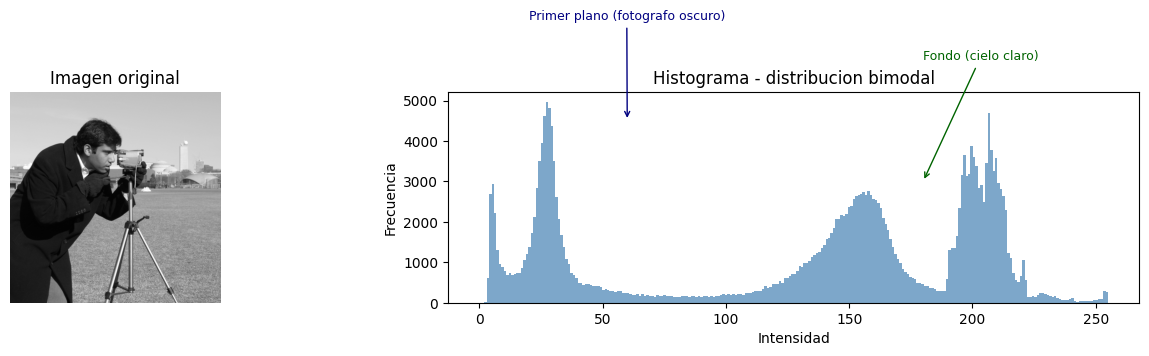

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].hist(img.ravel(), bins=256, color="steelblue", alpha=0.7)
axes[1].set_title("Histograma - distribucion bimodal")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")

# En camera: el fotografo (oscuro) es el objeto; el cielo (claro) es el fondo
label_obj = "Primer plano (fotografo oscuro)"
label_fondo = "Fondo (cielo claro)"

axes[1].annotate(label_obj, xy=(60, 4500), xytext=(20, 7000),
                 fontsize=9, color="navy",
                 arrowprops=dict(arrowstyle="->", color="navy"))
axes[1].annotate(label_fondo, xy=(180, 3000), xytext=(180, 6000),
                 fontsize=9, color="darkgreen",
                 arrowprops=dict(arrowstyle="->", color="darkgreen"))

plt.tight_layout()
plt.show()

# Nota: fondo != siempre oscuro. Otsu separa los dos grupos del histograma;
# cual es fondo y cual es objeto depende de la imagen concreta.


### 3.2 Visualización del criterio de Otsu — varianza entre clases

Otsu prueba **todos los umbrales posibles** (0 a 255) y para cada uno calcula la **varianza entre clases**: una medida de lo bien separados que quedan los dos grupos. El umbral óptimo es el que **maximiza** esta varianza — es decir, el que crea los dos grupos más diferentes posibles entre sí.

En la gráfica siguiente podemos ver este criterio en acción:


#### Como se calcula el score para cada umbral

Para cada umbral `t`, el algoritmo divide todos los pixeles en dos grupos y calcula:

- **Media de cada grupo**: el valor promedio de intensidad de los pixeles de cada lado.
- **Tamano de cada grupo**: cuantos pixeles hay en cada lado.
- **Score** = (diferencia entre medias)^2 x equilibrio de tamanos

El equilibrio de tamanos penaliza los cortes donde un grupo queda casi vacio. Un corte con grupos muy desiguales recibe un score bajo aunque sus medias esten muy separadas.

---

Por ejemplo, en la imagen `camera` (fotografo oscuro, cielo claro):

**Umbral = 10** (corte muy a la izquierda):
- Grupo oscuro: ~500 pixeles, media = 7
- Grupo claro: ~261.000 pixeles, media = 138
- Diferencia de medias = 131, pero el grupo oscuro es casi vacio
- Score: **bajo** - el corte no separa nada util

**Umbral = 87** (zona del valle en el histograma):
- Grupo oscuro: ~130.000 pixeles, media = 60
- Grupo claro: ~131.000 pixeles, media = 170
- Diferencia de medias = 110, ambos grupos tienen tamano similar
- Score: **alto** - este es el umbral de Otsu

**Umbral = 250** (corte muy a la derecha):
- Grupo oscuro: ~261.900 pixeles, media = 120
- Grupo claro: ~244 pixeles, media = 252
- Diferencia de medias = 132, pero el grupo claro es casi vacio
- Score: **bajo** - mismo problema que t=10 pero al reves

La curva azul de la grafica siguiente es ese score trazado para los 254 umbrales posibles. La linea roja marca el maximo: el umbral que mejor equilibra separacion y tamano de grupos.


#### Cómo se calcula el score para cada umbral

Para cada umbral , el algoritmo divide todos los píxeles en dos grupos y calcula tres cosas:

- **Intensidad media de cada grupo**: el valor promedio de los píxeles de cada lado del corte.
- **Tamaño de cada grupo**: cuántos píxeles hay en cada lado.
- **Score** = (diferencia entre medias)² × equilibrio de tamaños

El equilibrio de tamaños penaliza los cortes donde un grupo queda casi vacío. Un corte con grupos muy desiguales recibe un score bajo aunque sus medias estén muy separadas.

---

Por ejemplo, en la imagen  (fotógrafo oscuro ~valor 70, cielo claro ~valor 180):

| Umbral | Grupo oscuro | Grupo claro | Media oscuro | Media claro | Equilibrio | Score |
|--------|-------------|-------------|-------------|-------------|------------|-------|
| **t = 10** | 500 px | 261.644 px | 7 | 138 | muy desigual | bajo |
| **t = 87** | 130.000 px | 131.644 px | 60 | 170 | equilibrado | **alto** |
| **t = 250** | 261.900 px | 244 px | 120 | 252 | muy desigual | bajo |

Con : la diferencia de medias es grande (138 - 7 = 131), pero casi todos los píxeles caen en el grupo claro — el grupo oscuro es casi vacío. El score es bajo porque el corte no es útil.

Con : ambos grupos tienen un tamaño similar y sus medias están bien separadas. Ese equilibrio entre separación y tamaño produce el score máximo — ese es el umbral de Otsu.


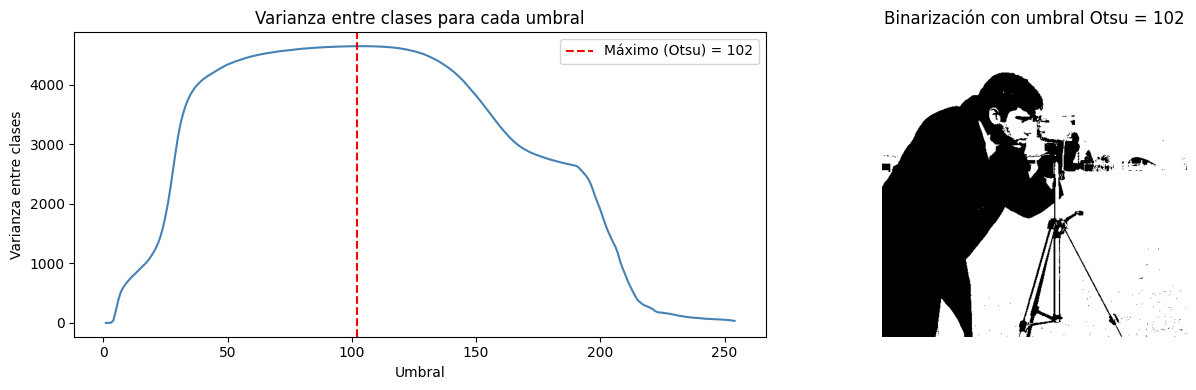

Otsu elige el umbral 102 porque maximiza la separación entre fondo y primer plano.


In [ ]:
# Calcular la varianza entre clases para cada umbral posible
varianzas = []
thresholds = np.arange(1, 255)

for t in thresholds:
    fondo = img[img < t]
    plano = img[img >= t]

    if len(fondo) == 0 or len(plano) == 0:
        varianzas.append(0)
        continue

    w0 = len(fondo) / img.size   # peso del fondo
    w1 = len(plano) / img.size   # peso del primer plano
    mu0 = fondo.mean()           # media del fondo
    mu1 = plano.mean()           # media del primer plano

    # Varianza entre clases: cuanto más separadas estén las medias, mejor
    var_entre = w0 * w1 * (mu0 - mu1) ** 2
    varianzas.append(var_entre)

umbral_otsu = threshold_otsu(img)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Curva de varianza entre clases
axes[0].plot(thresholds, varianzas, color='steelblue')
axes[0].axvline(umbral_otsu, color='red', linestyle='--',
                label=f'Máximo (Otsu) = {umbral_otsu}')
axes[0].set_title('Varianza entre clases para cada umbral')
axes[0].set_xlabel('Umbral')
axes[0].set_ylabel('Varianza entre clases')
axes[0].legend()

# Resultado final
axes[1].imshow(img > umbral_otsu, cmap='gray')
axes[1].set_title(f'Binarización con umbral Otsu = {umbral_otsu}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Otsu elige el umbral {umbral_otsu} porque maximiza la separación entre fondo y primer plano.')


## 4. Umbral en uint8 vs float — el valor cambia, el resultado no

El umbral calculado por Otsu depende de la escala de intensidades usada: si la imagen está en `uint8` [0, 255] el umbral será un entero (p.ej. 87); si está en `float` [0, 1] será un decimal (p.ej. 0.3412). Sin embargo, al aplicar cada umbral dentro de su escala correspondiente, **el resultado binario es idéntico**.


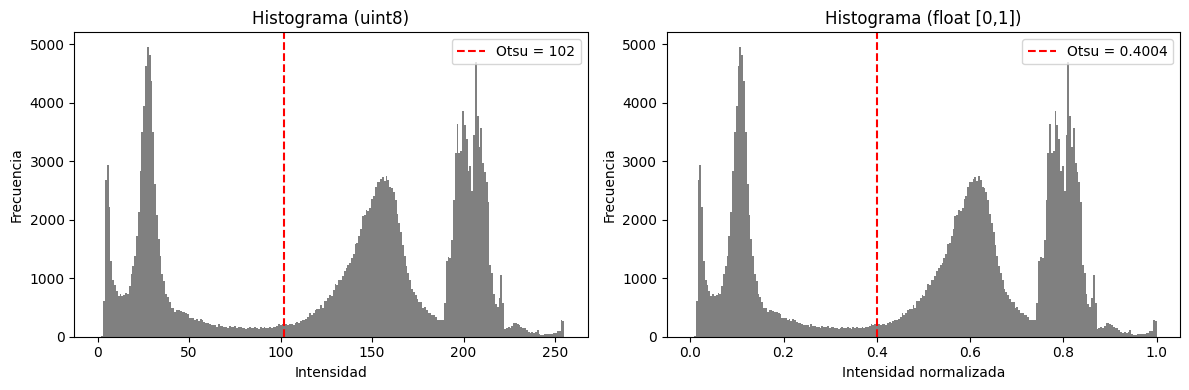

In [ ]:
# --- Cargar imagen ---
img = data.camera()

# --- Umbral en uint8 ---
umbral_uint8 = threshold_otsu(img)

# --- Conversión a float en [0,1] ---
img_f = util.img_as_float(img)

# --- Umbral en float ---
umbral_float = threshold_otsu(img_f)

# --- Visualización de histogramas ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma uint8
plt.sca(axes[0])
axes[0].hist(img.ravel(), bins=256, color="gray")
axes[0].axvline(umbral_uint8, color="red", linestyle="--", label=f"Otsu = {umbral_uint8}")
axes[0].set_title("Histograma (uint8)")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Histograma float [0,1]
plt.sca(axes[1])
axes[1].hist(img_f.ravel(), bins=256, color="gray")
axes[1].axvline(umbral_float, color="red", linestyle="--", label=f"Otsu = {umbral_float:.4f}")
axes[1].set_title("Histograma (float [0,1])")
axes[1].set_xlabel("Intensidad normalizada")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Generación de imágenes binarizadas

Aplicamos los dos umbrales (uno en `uint8`, otro en `float`) y verificamos que producen resultados visuales equivalentes.


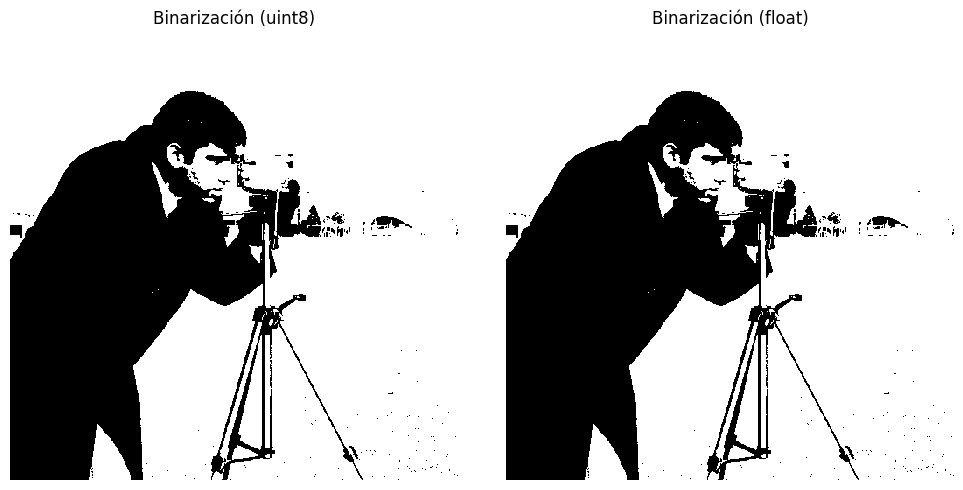

In [ ]:
# Binarización
bin_uint8 = img > umbral_uint8
bin_float = img_f > umbral_float

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Binarización usando uint8
plt.sca(axes[0])
io.imshow(bin_uint8, cmap="gray")
axes[0].set_title("Binarización (uint8)")
axes[0].axis("off")

# Binarización usando float [0,1]
plt.sca(axes[1])
io.imshow(bin_float, cmap="gray")
axes[1].set_title("Binarización (float)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Limpieza morfológica de la máscara binaria

Tras binarizar, la máscara suele contener **imperfecciones**: pequeños grupos de píxeles aislados clasificados erróneamente como primer plano (ruido), y pequeños agujeros dentro de objetos reales. La **morfología matemática** ofrece herramientas sencillas para limpiar estas imperfecciones.

Trabajaremos con tres operaciones en secuencia:
1. **Cierre morfológico** (`closing`): rellena agujeros pequeños dentro de los objetos.
2. **Eliminación de objetos pequeños** (`remove_small_objects`): descarta regiones aisladas menores de un área mínima.


### 6.1 Observar el ruido en la máscara original

Ampliamos una zona de la máscara para ver el ruido: píxeles aislados y agujeros dentro de las regiones detectadas.


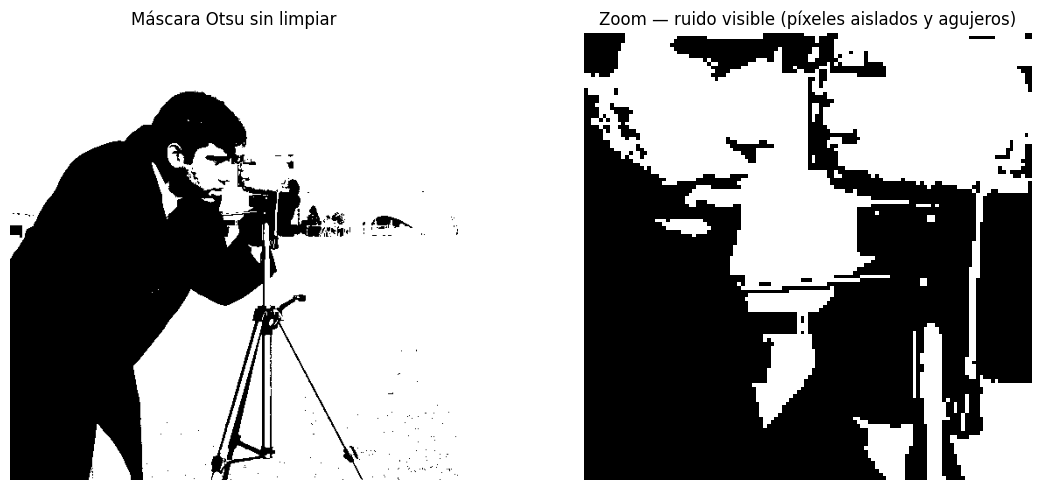

In [ ]:
# Máscara directa de Otsu (sin limpiar)
mascara_raw = img > umbral_otsu

# Zoom sobre una región con ruido visible (esquina superior izquierda)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mascara_raw, cmap='gray')
axes[0].set_title('Máscara Otsu sin limpiar')
axes[0].axis('off')

# Zoom sobre región de interés
region = mascara_raw[140:260, 200:320]
axes[1].imshow(region, cmap='gray', interpolation='nearest')
axes[1].set_title('Zoom — ruido visible (píxeles aislados y agujeros)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### 6.2 Paso 1 — Cierre morfológico (`closing`)

El cierre aplica una **dilatación seguida de erosión** usando un elemento estructurante (disco de radio `r`). El efecto: los agujeros pequeños dentro de las regiones blancas quedan **rellenados**. El radio controla el tamaño máximo de los agujeros que se cierran.


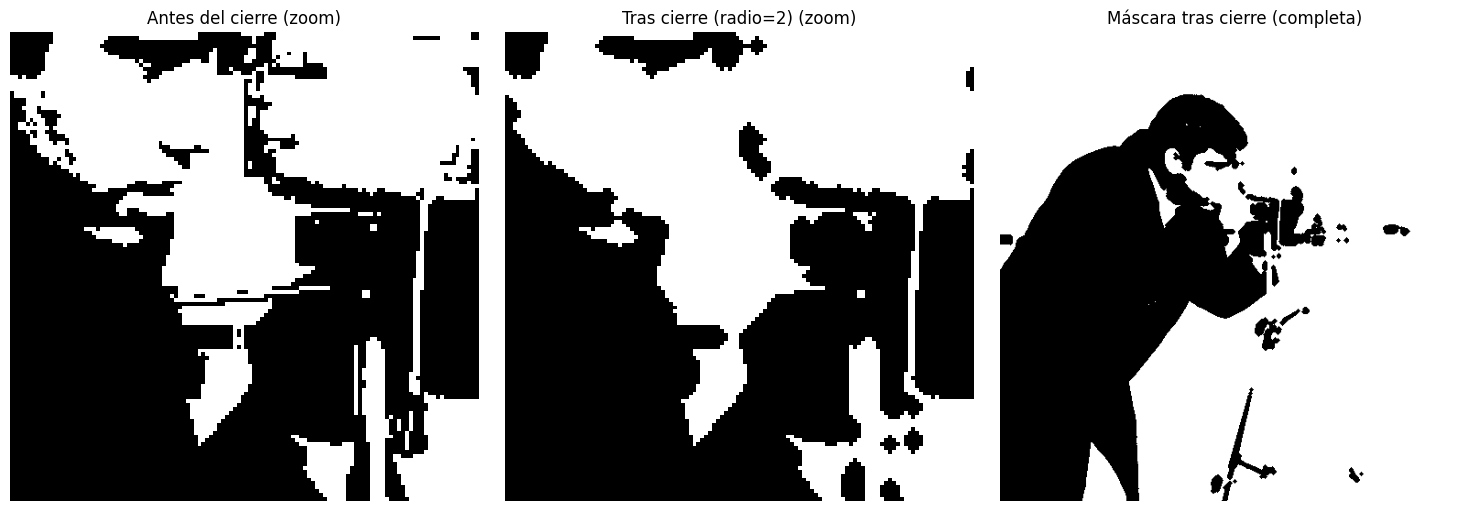

In [ ]:
from skimage.morphology import disk, closing, remove_small_objects

radio = 2
selem = disk(radio)
mascara_closed = closing(mascara_raw, selem)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mascara_raw[140:260, 200:320], cmap='gray', interpolation='nearest')
axes[0].set_title('Antes del cierre (zoom)')
axes[0].axis('off')

axes[1].imshow(mascara_closed[140:260, 200:320], cmap='gray', interpolation='nearest')
axes[1].set_title(f'Tras cierre (radio={radio}) (zoom)')
axes[1].axis('off')

axes[2].imshow(mascara_closed, cmap='gray')
axes[2].set_title('Máscara tras cierre (completa)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### 6.3 Paso 2 — Eliminación de regiones pequeñas (`remove_small_objects`)

El cierre no elimina los pequeños grupos de píxeles aislados que son más pequeños que el radio. `remove_small_objects` descarta todas las **componentes conexas** (grupos de píxeles blancos conectados) cuya área (número de píxeles) sea inferior a `min_size`.


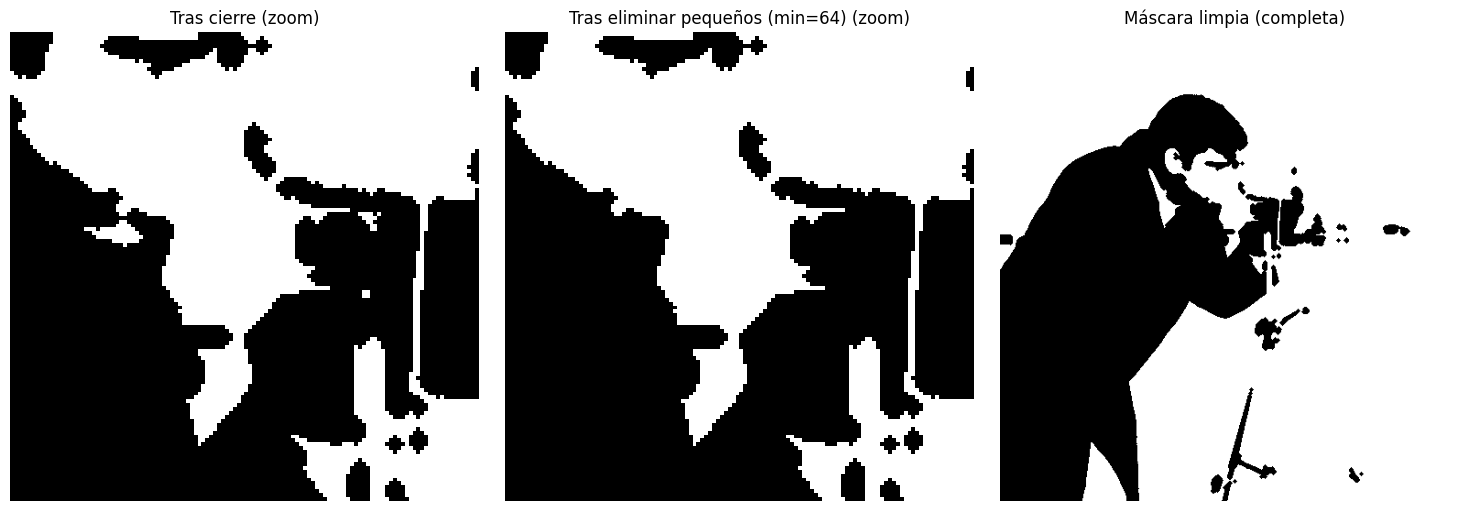

In [ ]:
min_size = 64  # descartar regiones con menos de 64 píxeles
mascara_clean = remove_small_objects(mascara_closed, min_size=min_size)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mascara_closed[140:260, 200:320], cmap='gray', interpolation='nearest')
axes[0].set_title('Tras cierre (zoom)')
axes[0].axis('off')

axes[1].imshow(mascara_clean[140:260, 200:320], cmap='gray', interpolation='nearest')
axes[1].set_title(f'Tras eliminar pequeños (min={min_size}) (zoom)')
axes[1].axis('off')

axes[2].imshow(mascara_clean, cmap='gray')
axes[2].set_title('Máscara limpia (completa)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### 6.4 Comparación completa: original → cierre → limpieza


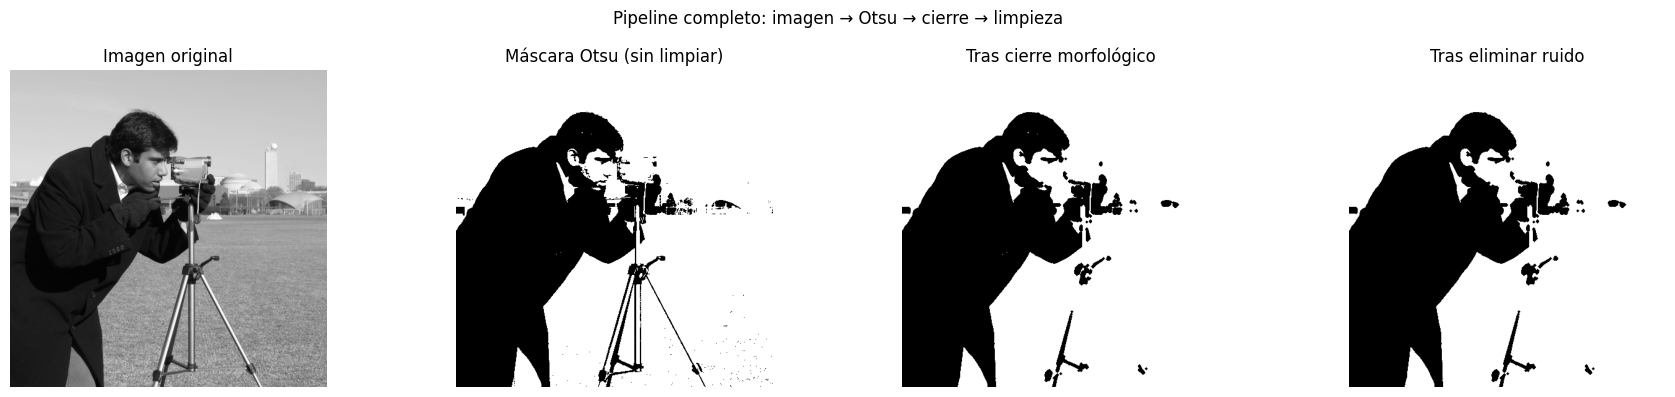

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pasos = [
    (img,           'Imagen original',              None),
    (mascara_raw,   'Máscara Otsu (sin limpiar)',   'gray'),
    (mascara_closed,'Tras cierre morfológico',      'gray'),
    (mascara_clean, 'Tras eliminar ruido',          'gray'),
]

for ax, (im, titulo, cmap) in zip(axes, pasos):
    ax.imshow(im, cmap=cmap)
    ax.set_title(titulo)
    ax.axis('off')

plt.suptitle('Pipeline completo: imagen → Otsu → cierre → limpieza', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Funciones reutilizables

Ahora que hemos visto cada paso por separado, los encapsulamos en dos funciones:

- `to_monochrome`: umbral fijo definido por el usuario.
- `apply_otsu`: umbral automático de Otsu con limpieza morfológica opcional (exactamente los pasos vistos en la sección anterior).


In [ ]:
def to_monochrome(img_gray, threshold=0.5):
    """
    Genera una imagen binaria aplicando un umbral fijo.

    Parámetros
    ----------
    img_gray : array_like
        Imagen en escala de grises. Puede estar en uint8 o en float [0,1].
    threshold : float
        Valor de umbral en el rango [0,1] si la imagen se convierte a float.

    Devuelve
    --------
    mask : ndarray (bool)
        Máscara booleana donde True indica los píxeles por encima del umbral.
    """
    arr = np.asarray(img_gray)
    if arr.dtype not in (np.float32, np.float64):
        arr = util.img_as_float(arr)
    return arr >= threshold


def apply_otsu(img_gray, clean=True, min_size=64, closing_radius=2):
    """
    Aplica el umbral automático de Otsu y genera una máscara binaria.

    Parámetros
    ----------
    img_gray : array_like
        Imagen en escala de grises (uint8 o float). Se convierte automáticamente a float.
    clean : bool
        Si es True, aplica un proceso de limpieza morfológica para eliminar ruido.
    min_size : int
        Tamaño mínimo de las regiones que se conservarán tras la limpieza.
    closing_radius : int
        Radio del elemento estructurante usado para el cierre morfológico.

    Devuelve
    --------
    mask : ndarray (bool)
        Máscara booleana directamente umbralizada con Otsu.
    mask_clean : ndarray (bool)
        Máscara tras aplicar cierre morfológico y eliminación de regiones pequeñas.
    thresh : float
        Valor del umbral calculado según el método de Otsu (en rango [0,1]).
    """
    arr = np.asarray(img_gray)
    if arr.dtype not in (np.float32, np.float64):
        arr = util.img_as_float(arr)

    thresh = threshold_otsu(arr)
    mask = arr >= thresh

    if clean:
        selem = morphology.disk(closing_radius)
        mask_closed = morphology.closing(mask, selem)
        mask_clean = morphology.remove_small_objects(mask_closed, min_size=min_size)
    else:
        mask_clean = mask

    return mask, mask_clean, thresh


## 8. Utilidades de visualización y métricas

Funciones de ayuda para mostrar imágenes, histogramas y métricas básicas. Se usan `io.imshow()` para imágenes y `plt` para gráficos no-imagenes.

In [ ]:
def show_image(ax, img, title=None, cmap=None):
    plt.sca(ax)
    io.imshow(img, cmap=cmap)
    if title:
        ax.set_title(title)
    ax.axis('off')

def plot_histogram_ax(ax, img, bins=256):
    arr = np.asarray(img)
    if arr.dtype != np.uint8:
        arr_plot = (util.img_as_float(arr) * 255).ravel()
    else:
        arr_plot = arr.ravel()
    ax.hist(arr_plot, bins=bins)
    ax.set_xlabel('Intensidad')
    ax.set_ylabel('Frecuencia')


## 9. Ejemplos prácticos

Se utilizan las mismas imágenes que en S1 (`img/santander.png` e `img/dark.jpg`) para mantener la continuidad entre sesiones. La imagen oscura se ecualiza con CLAHE antes de umbralizar, ilustrando la importancia del preprocesamiento previo a la umbralización.


Formas: (178, 283, 3) (178, 283) (400, 640)


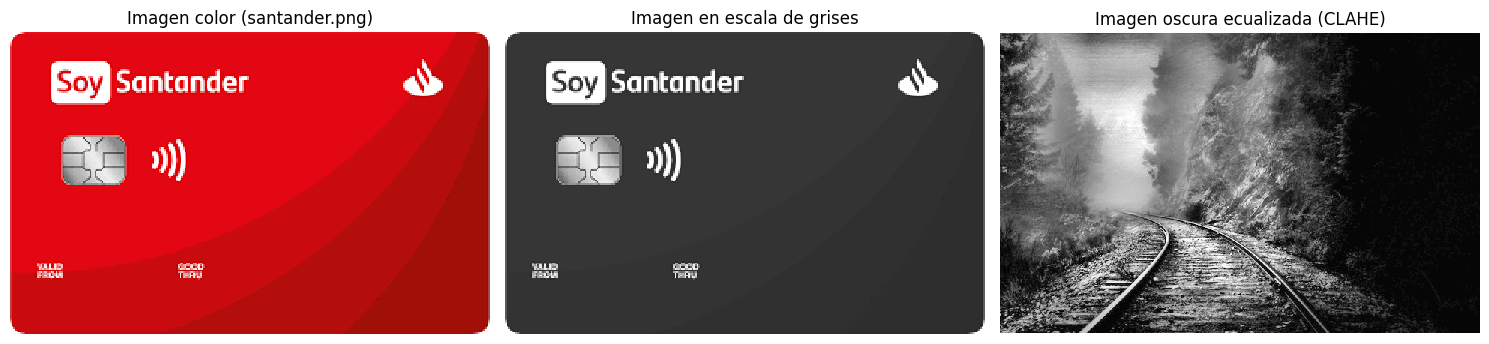

In [ ]:
# Cargar las mismas imágenes usadas en S1
img_src = io.imread('img/santander.png')
img_gray_src = color.rgb2gray(img_src)         # float64 [0,1]

# Imagen oscura: cargar y ecualizar (igual que en S1)
img_dark_bgr = cv2.imread('img/dark.jpg') if OPENCV_AVAILABLE else None
img_dark_rgb = cv2.cvtColor(img_dark_bgr, cv2.COLOR_BGR2RGB) if OPENCV_AVAILABLE else io.imread('img/dark.jpg')
img_dark_gray = color.rgb2gray(img_dark_rgb)
img_dark_gray_equalized = exposure.equalize_adapthist(img_dark_gray, clip_limit=0.03)

print('Formas:', img_src.shape, img_gray_src.shape, img_dark_gray.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_image(axes[0], img_src, title='Imagen color (santander.png)')
show_image(axes[1], img_gray_src, title='Imagen en escala de grises')
show_image(axes[2], img_dark_gray_equalized, title='Imagen oscura ecualizada (CLAHE)')
plt.tight_layout()
plt.show()


### 6.1 Aplicación de Otsu sobre la imagen en gris (ejemplo `img_gray`)

Se calcula el umbral de Otsu, se muestra el histograma con la línea del umbral y se visualizan las máscaras antes y después de limpiar morfológicamente.

Umbral Otsu (img_gray): 0.5301


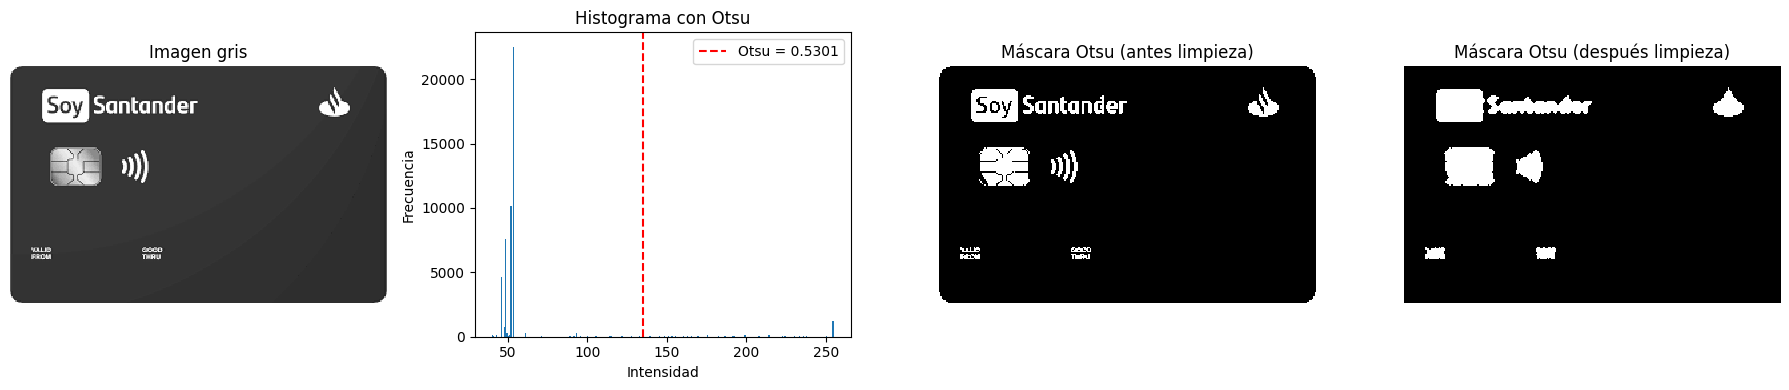

% píxeles primer plano (img_gray, tras limpieza): 6.83%


In [ ]:
# Otsu sobre img_gray_src
mask, mask_clean, thresh = apply_otsu(img_gray_src, clean=True, min_size=100, closing_radius=2)
print(f'Umbral Otsu (img_gray): {thresh:.4f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
show_image(axes[0], img_gray_src, title='Imagen gris')

# histograma
plt.sca(axes[1])
plot_histogram_ax(axes[1], img_gray_src)
# cuando la imagen es float, thresh ya está en [0,1]
# plot_histogram_ax escala siempre a 0-255; thresh está en [0,1] → multiplicar por 255
axes[1].axvline(thresh * 255, color='red', linestyle='--', label=f'Otsu = {thresh:.4f}')
axes[1].legend()
axes[1].set_title('Histograma con Otsu')

show_image(axes[2], mask, title='Máscara Otsu (antes limpieza)', cmap='gray')
show_image(axes[3], mask_clean, title='Máscara Otsu (después limpieza)', cmap='gray')
plt.tight_layout()
plt.show()

pct = 100.0 * mask_clean.sum() / mask_clean.size
print(f'% píxeles primer plano (img_gray, tras limpieza): {pct:.2f}%')


### 6.2 ¿Qué pasa si umbralizamos la imagen oscura SIN ecualizar?

Antes de aplicar Otsu sobre la imagen oscura, conviene ver qué ocurre si se omite el paso de ecualización. Recuerda que Otsu asume un histograma **bimodal**: si todos los píxeles están concentrados en valores bajos (imagen oscura), no hay dos picos diferenciados y Otsu no puede encontrar un valle significativo.


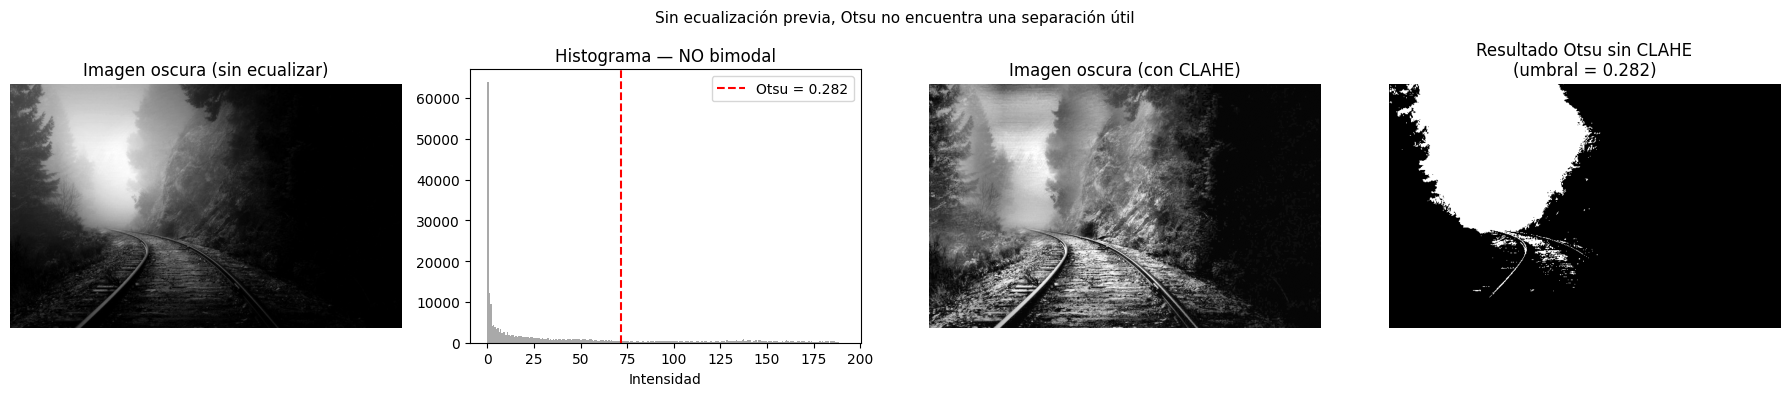

In [ ]:
# Otsu directamente sobre la imagen oscura SIN ecualizar
_, mascara_dark_raw, thresh_dark_raw = apply_otsu(img_dark_gray, clean=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_dark_gray, cmap='gray')
axes[0].set_title('Imagen oscura (sin ecualizar)')
axes[0].axis('off')

axes[1].hist((img_dark_gray * 255).ravel(), bins=256, color='darkgray')
axes[1].axvline(thresh_dark_raw * 255, color='red', linestyle='--',
                label=f'Otsu = {thresh_dark_raw:.3f}')
axes[1].set_title('Histograma — NO bimodal')
axes[1].set_xlabel('Intensidad')
axes[1].legend()

axes[2].imshow(img_dark_gray_equalized, cmap='gray')
axes[2].set_title('Imagen oscura (con CLAHE)')
axes[2].axis('off')

axes[3].imshow(mascara_dark_raw, cmap='gray')
axes[3].set_title(f'Resultado Otsu sin CLAHE\n(umbral = {thresh_dark_raw:.3f})')
axes[3].axis('off')

plt.suptitle('Sin ecualización previa, Otsu no encuentra una separación útil', fontsize=11)
plt.tight_layout()
plt.show()


### 9.3 Aplicación de Otsu sobre la imagen oscura ecualizada (con CLAHE)

Se repite el proceso sobre la imagen ecualizada para ilustrar la recomendación de aplicar normalización o equalización previa a la umbralización cuando la iluminación es desigual.

Umbral Otsu (img_dark_gray_equalized): 0.3340


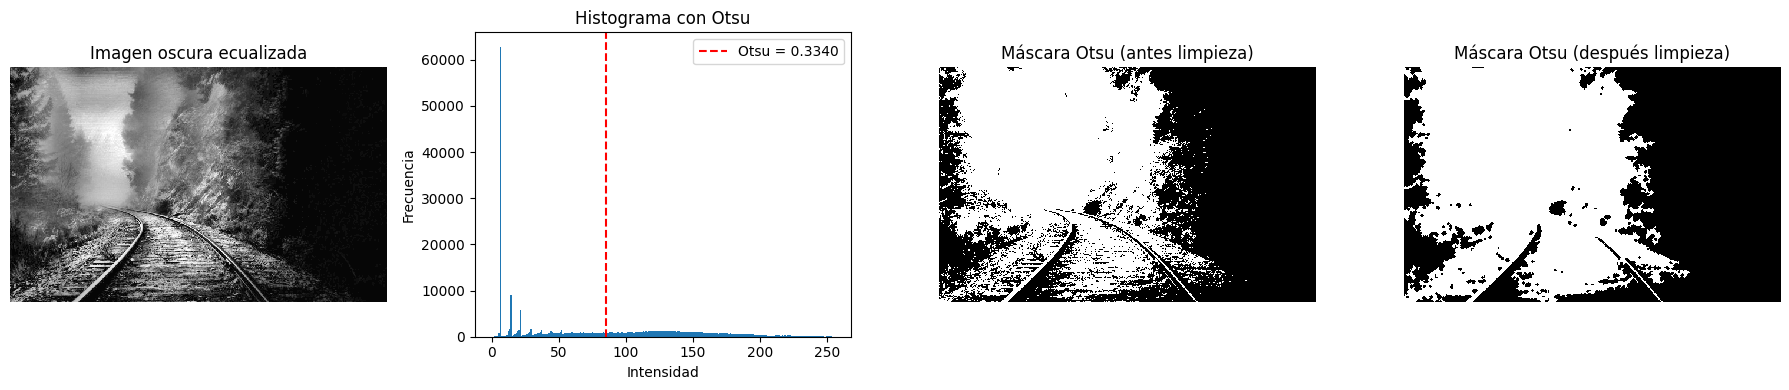

% píxeles primer plano (img_dark, tras limpieza): 50.95%


In [ ]:
# Otsu sobre img_dark_gray_equalized
mask_d, mask_d_clean, thresh_d = apply_otsu(img_dark_gray_equalized, clean=True, min_size=100, closing_radius=2)
print(f'Umbral Otsu (img_dark_gray_equalized): {thresh_d:.4f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
show_image(axes[0], img_dark_gray_equalized, title='Imagen oscura ecualizada', cmap='gray')

plt.sca(axes[1])
plot_histogram_ax(axes[1], img_dark_gray_equalized)
# plot_histogram_ax escala siempre a 0-255; thresh está en [0,1] → multiplicar por 255
axes[1].axvline(thresh_d * 255, color='red', linestyle='--', label=f'Otsu = {thresh_d:.4f}')
axes[1].legend()
axes[1].set_title('Histograma con Otsu')

show_image(axes[2], mask_d, title='Máscara Otsu (antes limpieza)', cmap='gray')
show_image(axes[3], mask_d_clean, title='Máscara Otsu (después limpieza)', cmap='gray')
plt.tight_layout()
plt.show()

pct_d = 100.0 * mask_d_clean.sum() / mask_d_clean.size
print(f'% píxeles primer plano (img_dark, tras limpieza): {pct_d:.2f}%')


## 8. Etiquetado de regiones y bounding boxes

Una vez obtenida una máscara limpia, podemos identificar cada **región conectada** (grupo de píxeles blancos contiguos) y asignarle una etiqueta única. Esto permite extraer propiedades geométricas de cada objeto detectado: área, centroide, bounding box, etc.

Es el primer paso hacia tareas de **detección y conteo de objetos**.


Regiones encontradas (área >=200): 2


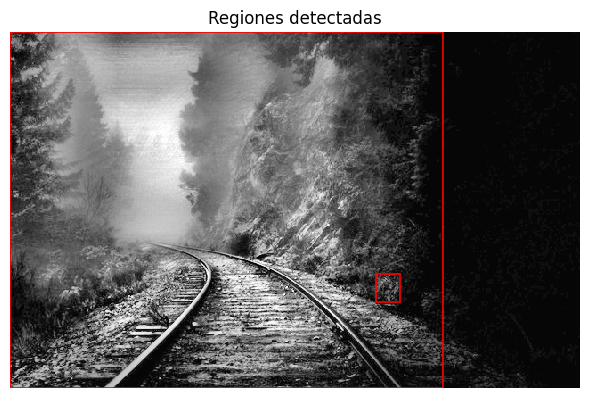

 id     area                 bbox                                 centroid
  1 129615.0     (0, 0, 400, 486) (189.19218454654168, 211.23308259074952)
  2    336.0 (272, 410, 303, 437)             (286.125, 422.9702380952381)


In [ ]:
def label_and_describe(mask, min_area=100):
    labeled = measure.label(mask)
    props = measure.regionprops(labeled)
    # Filtrar por área
    filtered = [p for p in props if p.area >= min_area]
    return labeled, filtered

# Aplicar a la máscara limpia del ejemplo oscuro
labeled, props = label_and_describe(mask_d_clean, min_area=200)
print(f'Regiones encontradas (área >=200): {len(props)}')

# Visualizar bounding boxes
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
show_image(ax, img_dark_gray_equalized, title='Regiones detectadas', cmap='gray')
for p in props:
    minr, minc, maxr, maxc = p.bbox
    rect = plt.Rectangle((minc, minr), maxc-minc, maxr-minr,
                         edgecolor='red', facecolor='none', linewidth=1.2)
    ax.add_patch(rect)
plt.tight_layout()
plt.show()

# Mostrar tabla resumida de regiones
rows = []
for i,p in enumerate(props):
    rows.append({'id': i+1, 'area': p.area, 'bbox': p.bbox, 'centroid': p.centroid})

import pandas as pd
if rows:
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
else:
    print('No hay regiones que mostrar con el umbral de área seleccionado.')


## 11. Recomendaciones finales

- Aplicar equalización o normalización local antes de umbralizar cuando la iluminación es desigual.
- Otsu es efectivo en presencia de histogramas bimodales; en otros casos considerar métodos adaptativos o aprendizaje supervisado.
- Ajustar parámetros morfológicos en función de la escala de los objetos.
- Para tareas de conteo o detección, combinar máscaras binarizadas con etiquetado y filtrado por propiedades geométricas.